In [11]:
from urllib.request import urlopen

import numpy as np
import pandas as pd
%matplotlib inline

import xgboost as xgb
from matplotlib import pyplot as plt
from sklearn.datasets import  load_digits, load_iris
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

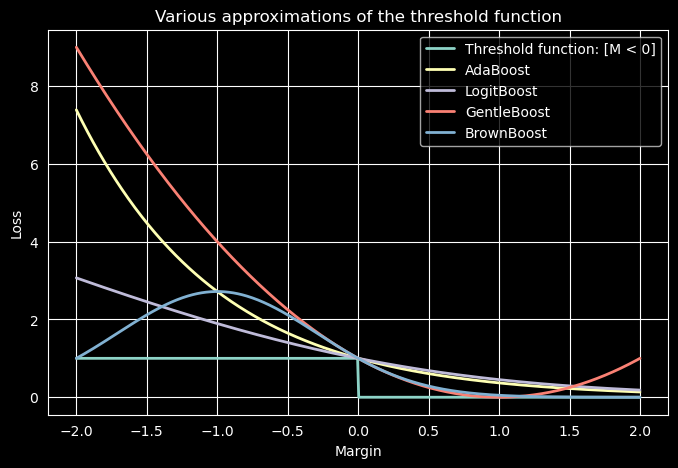

In [12]:
x = np.linspace(-2, 2, 500)

plt.figure(figsize=(8, 5))
plt.plot(x, x<0, lw=2, label="Threshold function: [M < 0]")
plt.plot(x, np.exp(-x), lw=2, label="AdaBoost")
plt.plot(x, np.log2(1 + np.exp(-x)), lw=2, label="LogitBoost")
plt.plot(x, (1 - x) ** 2, lw=2, label="GentleBoost")
plt.plot(x, np.exp(-x * (x + 2)), lw=2, label="BrownBoost")
plt.title("Various approximations of the threshold function")
plt.legend(loc="best")
plt.xlabel("Margin")
plt.ylabel("Loss");

In [13]:
n_train = 150
n_test = 1000
noise = 0.1

def f(x):
    x = x.ravel()

    return np.exp(-(x ** 2)) + 1.5 * np.exp(-((x - 2) ** 2))

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = (
        np.exp(-(X ** 2))
        + 1.5 * np.exp(-((X - 2) ** 2))
        + np.random.normal(0.0, noise, n_samples)
    )
    X = X.reshape(((n_samples, 1)))

    return X, y

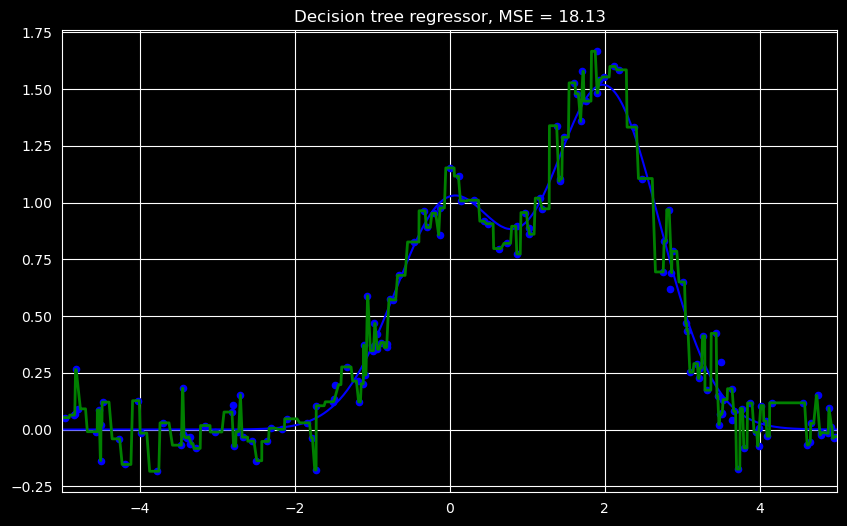

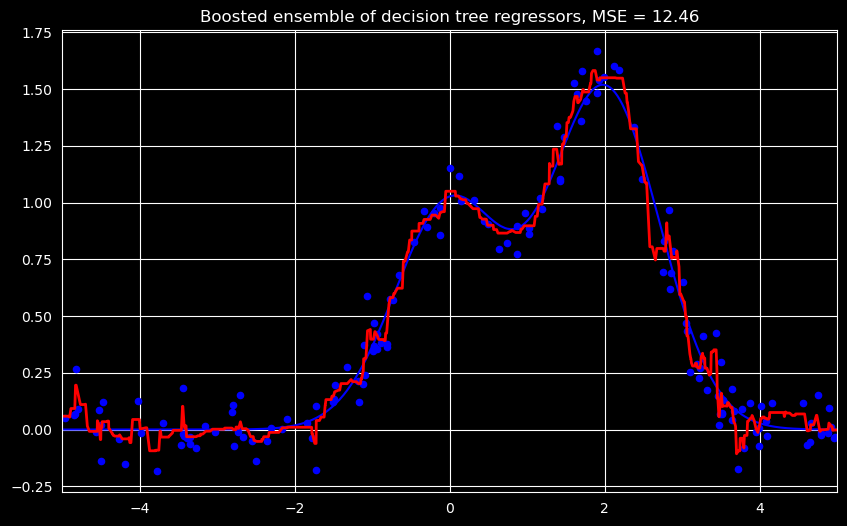

In [14]:
X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

dtree = DecisionTreeRegressor(random_state=0)
dtree.fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree regressor, MSE = %.2f" % np.sum((y_test - d_predict) ** 2))

gbtree = GradientBoostingRegressor(n_estimators=100, subsample=0.5, random_state=42)
gbtree.fit(X_train, y_train)
gb_predict = gbtree.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, gb_predict, "r", lw=2)
plt.xlim([-5, 5])
plt.title("Boosted ensemble of decision tree regressors, MSE = %.2f" % np.sum((y_test - gb_predict) ** 2));

### AdaBoost

In [24]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
raw_data = urlopen(url)
data = np.loadtxt(raw_data, delimiter=",")

X_train, X_test, y_train, y_test = train_test_split(
    data[:, :8], data[:, 8], random_state=0
)

dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), random_state=42).fit(
    X_train, y_train
)

print("Decision tree accuracy: %.2f" % dt.score(X_test, y_test))
print("AdaBoost accuracy: %.2f" % ada.score(X_test, y_test))

Decision tree accuracy: 0.71
AdaBoost accuracy: 0.77


# Xgboost

In [18]:
iris = load_iris()
X = iris["data"]
y = iris["target"]
kf = KFold(n_splits=5, shuffle=True, random_state=13)
for train_index, test_index in kf.split(y):
    xgb_model = xgb.XGBClassifier().fit(X[train_index], y[train_index])
    predictions = xgb_model.predict(X[test_index])
    actuals = y[test_index]
    print(confusion_matrix(actuals, predictions))

[[ 9  0  0]
 [ 0  8  0]
 [ 0  1 12]]
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
[[9 0 0]
 [0 9 1]
 [0 2 9]]
[[12  0  0]
 [ 0 10  1]
 [ 0  0  7]]
[[10  0  0]
 [ 1 10  0]
 [ 0  0  9]]


In [19]:
X = iris["data"]
y = iris["target"]

xgb_model = xgb.XGBRegressor()
xgb_grid = GridSearchCV(xgb_model, {"max_depth": [2, 4, 6]}, verbose=1)
xgb_grid.fit(X, y)
print(xgb_grid.best_score_)
print(xgb_grid.best_params_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
0.293390953540802
{'max_depth': 6}


In [22]:
# Ранняя остановка используется для того, чтобы прекратить обучение модели (градиентный спуск), если ошибка за несколько итераций не уменьшилась

digits = load_digits()

X = digits["data"]
y = digits["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=17)
clf = xgb.XGBClassifier()

clf = xgb.XGBClassifier(
    early_stopping_rounds=10,
    eval_metric="merror"
)

clf.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-merror:0.14889
[1]	validation_0-merror:0.10667
[2]	validation_0-merror:0.08667
[3]	validation_0-merror:0.08000
[4]	validation_0-merror:0.07556
[5]	validation_0-merror:0.07333
[6]	validation_0-merror:0.07333
[7]	validation_0-merror:0.07333
[8]	validation_0-merror:0.07333
[9]	validation_0-merror:0.07111
[10]	validation_0-merror:0.07111
[11]	validation_0-merror:0.06667
[12]	validation_0-merror:0.06444
[13]	validation_0-merror:0.06222
[14]	validation_0-merror:0.06000
[15]	validation_0-merror:0.06000
[16]	validation_0-merror:0.06222
[17]	validation_0-merror:0.06000
[18]	validation_0-merror:0.06222
[19]	validation_0-merror:0.06000
[20]	validation_0-merror:0.05778
[21]	validation_0-merror:0.05778
[22]	validation_0-merror:0.05556
[23]	validation_0-merror:0.05556
[24]	validation_0-merror:0.05556
[25]	validation_0-merror:0.05333
[26]	validation_0-merror:0.05111
[27]	validation_0-merror:0.05333
[28]	validation_0-merror:0.04889
[29]	validation_0-merror:0.04667
[30]	validation_0-me

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

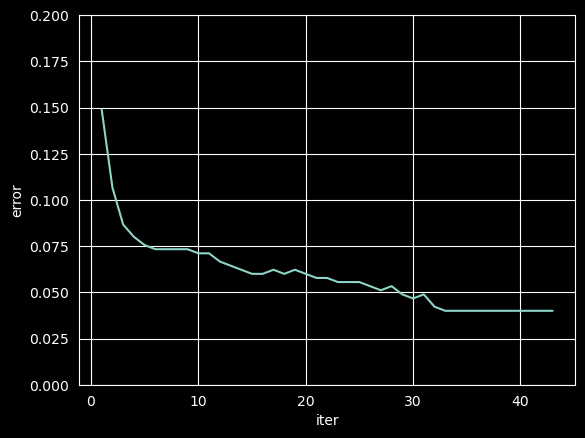

In [23]:
errors_by_iter = clf.evals_result()["validation_0"]["merror"]
plt.plot(range(1, len(errors_by_iter) + 1), errors_by_iter)
plt.xlabel("iter")
plt.ylabel("error")
plt.ylim(0, 0.2);